# 

# HW 1 - Multiple Linear Regression

Using OLS to predict the arrival delay using 3 given parameters, namely Departure Delay, Airtime and Distance.


In [28]:
# YOUR CODE HERE - you can create as many additional Markdown or Code cells as needed
# Suman's code
# importing libraries and data, statsmodel and scatter included
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import scatter_matrix
df=pd.read_csv("T_ONTIME_REPORTING.csv")

# Note: The data file has multiple columns, which contains a lot of parameters.
# I realized that I don't need to use all of them
# let's now get the required data columns from the CSV file
data=df[["ARR_DELAY", "DEP_DELAY", "AIR_TIME", "DISTANCE"]].dropna() # so that empty values are rejected


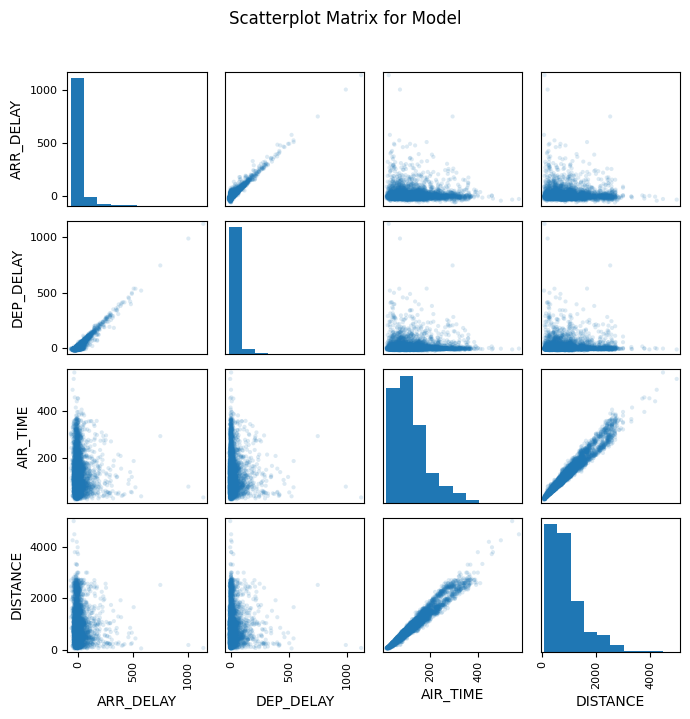

In [29]:
# time to plot!
data_plot=data.sample(n=5000, random_state=42)
scatter_matrix(data_plot,figsize=(7, 7),diagonal="hist",alpha=0.15)
plt.suptitle("Scatterplot Matrix for Model", y=1.02)
plt.tight_layout()
plt.show()


Description of the Results:
The scatterplot simply looks at the relationships between the chosen parameters and gives us a preliminary idea of what to expect from our model because the predicted data must show similarity to the training data and respect those relationships(the magnitude will heavily depend on how the model is trained). We have chosen 4 parameters(including Arrival Delay), so we obtain a scatterplot containing 16 squares.

In [30]:
# fit the model
y=data["ARR_DELAY"]
X=data[["DEP_DELAY", "AIR_TIME", "DISTANCE"]]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              ARR_DELAY   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                 2.929e+06
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:09:22   Log-Likelihood:            -2.1328e+06
No. Observations:              517222   AIC:                         4.266e+06
Df Residuals:                  517218   BIC:                         4.266e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.3010      0.044   -233.579      0.0

In [31]:
# ANOVA Test
print("F-statistic:", model.fvalue)
print("F-test p-value:", model.f_pvalue)

F-statistic: 2928668.584712569
F-test p-value: 0.0


In [32]:
# Individual coefficient tests
print("\nCoefficients:")
print(model.params)
print("\nT-statistics:")
print(model.tvalues)
print("\nP-values:")
print(model.pvalues)


Coefficients:
const       -10.301026
DEP_DELAY     1.014570
AIR_TIME      0.279497
DISTANCE     -0.034730
dtype: float64

T-statistics:
const        -233.579308
DEP_DELAY    2957.662780
AIR_TIME      206.208015
DISTANCE     -213.906452
dtype: float64

P-values:
const        0.0
DEP_DELAY    0.0
AIR_TIME     0.0
DISTANCE     0.0
dtype: float64


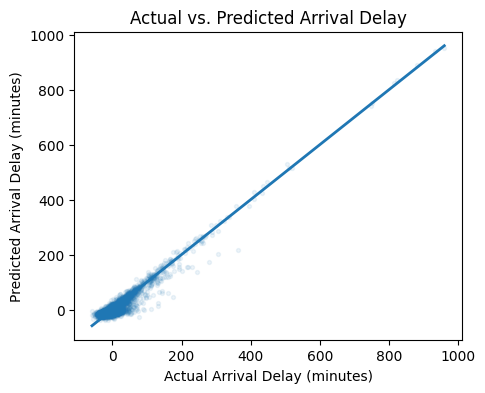

In [33]:
plot_data = pd.DataFrame({"actual": y,"predicted": y_pred}).sample(n=5000, random_state=77)# use any random number
plt.figure(figsize=(5, 4))
plt.scatter(plot_data["actual"],plot_data["predicted"],alpha=0.08,s=8)
low = min(plot_data["actual"].min(), plot_data["predicted"].min())
high = max(plot_data["actual"].max(), plot_data["predicted"].max())
plt.plot([low, high], [low, high], linewidth=2)
plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title("Actual vs. Predicted Arrival Delay")
plt.show()